In [ ]:
from pathlib import Path
import numpy as np

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

import umap.umap_ as umap
from scipy.spatial.distance import cosine

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import pandas as pd

/home/wuhlmann/miniforge3/envs/lamah-ce_lstm/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [1]:
import pickle

with open("/home/wuhlmann/BA/data/processed_data/cell_states/full_q_512_3011_185525_cell_states.p", "rb") as f:
    test_state_dict = pickle.load(f)

In [33]:
test_state_dict_o = dict(sorted(test_state_dict.items(), key=lambda kv:int(kv[0])))

test_state_dict_o.keys()

dict_keys(['1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '30', '32', '33', '34', '35', '36', '37', '38', '39', '40', '41', '42', '43', '44', '45', '46', '47', '48', '49', '50', '51', '52', '53', '54', '55', '56', '57', '58', '59', '60', '61', '62', '63', '64', '65', '66', '67', '68', '69', '70', '71', '72', '73', '74', '75', '76', '77', '78', '79', '80', '81', '82', '83', '84', '85', '86', '87', '88', '89', '90', '91', '92', '93', '94', '95', '96', '97', '98', '99', '100', '101', '102', '103', '104', '105', '106', '107', '108', '109', '110', '111', '112', '113', '114', '115', '116', '117', '118', '119', '120', '121', '122', '123', '124', '125', '126', '127', '128', '129', '130', '131', '132', '133', '134', '135', '136', '137', '138', '139', '140', '141', '142', '143', '144', '145', '147', '148', '149', '150', '151', '152', '153', '154', '155', '156', '157', '158', '159

In [34]:
with open("/home/wuhlmann/BA/data/processed_data/test_splits/strata_ids_incl_651.txt", "rb") as f: 
    strata_map = pd.read_table(f,header=0, sep=",")

strata_map.set_index("ID", inplace=True)
strata_map.rename(columns={"0":"strata"}, inplace=True)

for k in test_state_dict_o.keys():
    
    if int(k) not in strata_map.index:
        print(k)

In [74]:
with open("/home/wuhlmann/BA/data/processed_data/cell_states/full_q_512_3011_185525_cell_states_410.p", "rb") as f: 
    embed_410 = pickle.load(f)

with open("/home/wuhlmann/BA/data/processed_data/cell_states/full_q_512_3011_185525_cell_states_553.p", "rb") as f: 
    embed_553 = pickle.load(f)

In [78]:
mode = "raw"

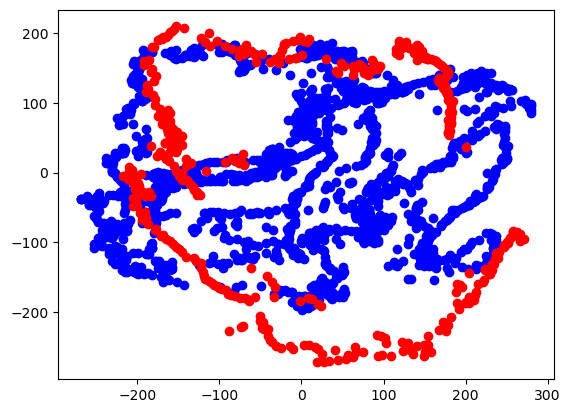

In [79]:
fig, axs = plt.subplots(1,1)

axs.scatter(embed_410[mode][:,0], embed_410[mode][:,1], c="blue")
axs.scatter(embed_553[mode][:,0], embed_553[mode][:,1], c="red")

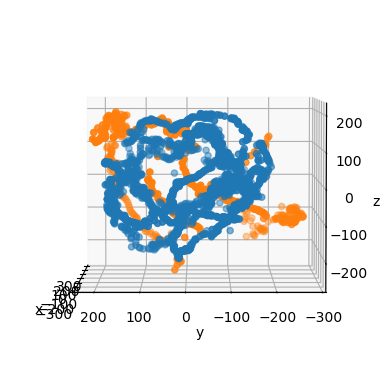

In [81]:
fig = plt.figure()
ax = fig.add_subplot(111,projection="3d")

ax.scatter(embed_410[mode][:,0], embed_410[mode][:,1],embed_410[mode][:,2])
ax.scatter(embed_553[mode][:,0], embed_553[mode][:,1],embed_553[mode][:,2])
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")

ax.view_init(elev=4, azim=180)
plt.show()

In [49]:
# test on seasonal data of one basin
basin_116 = test_state_dict["116"]["c_last"]

basin_116_embed = mds_3d.fit_transform(basin_116)

/home/wuhlmann/miniforge3/envs/lamah-ce_lstm/lib/python3.10/site-packages/sklearn/manifold/_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(


: 

/home/wuhlmann/miniforge3/envs/lamah-ce_lstm/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


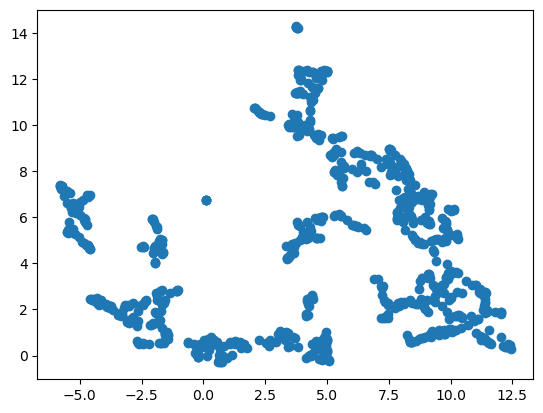

In [ ]:
reducer = umap.UMAP(
    n_components=2, 
    n_neighbors=5,
    min_dist=0.1,
    random_state=42
)

m2d = reducer.fit_transform(means)


fig, ax = plt.subplots(1,1)

ax.scatter(m2d[:,0],m2d[:,1])


In [ ]:
test_state_dict["116"]["2d_mean"]

In [ ]:
mean_101 = ordered_states[0].mean(axis=0)
mean_102 = ordered_states[1].mean(axis=0)

print(cosine(mean_101, mean_102))

In [ ]:
mode = "normal"

In [ ]:
normalizer = StandardScaler()

pca = PCA(0.9,svd_solver='full', random_state=42)

pca_101 = pca.fit_transform(normalizer.fit_transform(ordered_states[0]))
pca_102 = pca.transform(normalizer.fit_transform(ordered_states[1]))

reducer = umap.UMAP(
    n_components=2, 
    n_neighbors=100,
    min_dist=0.5,
    random_state=42
)

if mode == "raw": 
    states_101 = reducer.fit_transform(ordered_states[0])
    states_102 = reducer.transform(ordered_states[1])
elif mode == "normal": 
    states_101 = reducer.fit_transform(normalizer.fit_transform(ordered_states[0]))
    states_102 = reducer.fit_transform(normalizer.fit_transform(ordered_states[1]))
elif mode == "pca": 
    states_101 = reducer.fit_transform(pca_101)
    states_102 = reducer.transform(pca_102)



In [ ]:
fig, axs = plt.subplots(1,2, figsize=(10,5))

for i,ds in enumerate([states_101, states_102]):

    idx = np.arange(len(ds))
    axs[i].scatter(ds[:365,0],ds[:365,1], cmap="viridis")
    axs[i].title.set_text(f"{basin_ids[i]}")

In [ ]:
fig, ax = plt.subplots(1,1, figsize=(8,8))

ax.scatter(states_101[:365,0],states_101[:365,1], color="red")
ax.scatter(states_102[:365,0],states_102[:365,1], color="blue")

In [ ]:
fig = plt.figure()
ax = fig.add_subplot(111,projection="3d")

ax.scatter(states_101[:,0], states_101[:,1],states_101[:,2], c=point_colors)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")

ax.view_init(elev=10, azim=45)
plt.show()